In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


## Setup, Imports, and MLflow Initialization

In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Found existin

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score 
from sklearn.feature_selection import RFE

import dagshub
import mlflow
import mlflow.sklearn
import os

In [4]:
dagshub.init(repo_owner='mkoko22', repo_name='Titanic-Kaggle-Competition-', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a4145fcb-2f62-4630-b354-48e0568d86a1&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e59ccfd7f4c326d63ea8d974342cf5b38d40ad23cbeeefdc3dc78c6e93eae4ec




Accessing as mkoko22

Initialized MLflow to track repo "mkoko22/Titanic-Kaggle-Competition-"

Repository mkoko22/Titanic-Kaggle-Competition- initialized!

## Part 1. Loading and Inspecting the Data
Before we can build any models, we need to bring our data into the notebook and understand what it looks like. We will load both the training data (which has the `Survived` answers) and the test data (which we will predict on later).

Using pandas `.head()`, we can see the first few rows of our dataset, and `.info()` gives us a summary of the data types and missing values.

In [5]:
train_data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
display(train_data.head())
print("\n--- Training Data Info ---")
train_data.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Part 2. Exploratory Data Analysis: Finding Missing Data
In the real world, data is rarely perfect. Machine learning models usually cannot handle missing values (NaN). Let's see exactly how much missing data we are dealing with in our training set.

In [6]:
missing_train = train_data.isnull().sum()
print("--- Missing values in Training Data ---")
print(missing_train[missing_train > 0].sort_values(ascending=False))
print("\n") 
missing_test = test_data.isnull().sum()
print("--- Missing values in Test Data ---")
print(missing_test[missing_test > 0].sort_values(ascending=False))

--- Missing values in Training Data ---
Cabin       687
Age         177
Embarked      2
dtype: int64


--- Missing values in Test Data ---
Cabin    327
Age       86
Fare       1
dtype: int64


## Part 3. Visualizing Relationships
Data analysis isn't just about finding errors; it's about finding patterns! Let's import some visualization libraries to see how certain features affect survival rates. 

Historically, we know the rule on the Titanic was "Women and children first," and class likely played a role in who got to the lifeboats. Let's verify this by visualizing Survival rates based on `Sex` and `Pclass` (Passenger Class).

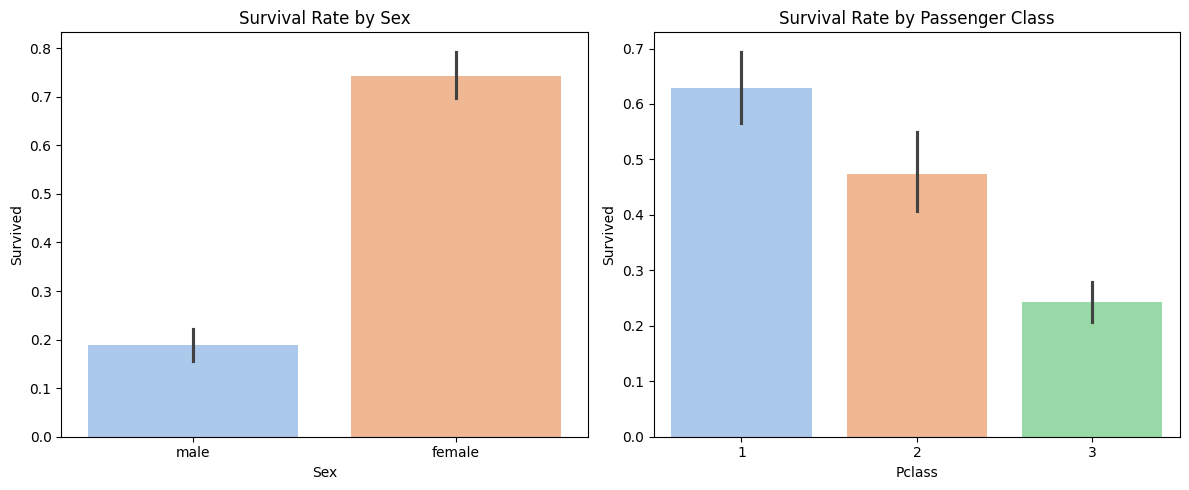

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Sex', y='Survived', data=train_data, ax=axes[0], palette='pastel', hue='Sex', legend=False)
axes[0].set_title('Survival Rate by Sex')
sns.barplot(x='Pclass', y='Survived', data=train_data, ax=axes[1], palette='pastel', hue='Pclass', legend=False)
axes[1].set_title('Survival Rate by Passenger Class')
plt.tight_layout()
plt.show()

## Part 4. Data Cleaning: Handling Missing Values
We saw that `Cabin`, `Age`, `Embarked`, and `Fare` have missing values. 

**Important Rule (Avoiding Data Leakage):** We will calculate the fill values (median and mode) using *only* our training data. Then, we will use those exact values to fill the missing spots in *both* our training and test sets!

* **Cabin:** Too many missing values. We will drop it.
* **Age & Fare:** Fill with the median (calculated from the training set).
* **Embarked:** Fill with the mode (the most common port, calculated from the training set).

In [8]:
with mlflow.start_run(run_name="Data_Preparation"):
    
    median_age = train_data['Age'].median()
    median_fare = train_data['Fare'].median()
    mode_embarked = train_data['Embarked'].mode()[0]
    
    mlflow.log_param("imputation_median_age", median_age)
    mlflow.log_param("imputation_median_fare", median_fare)
    mlflow.log_param("imputation_mode_embarked", mode_embarked)

    datasets = [train_data, test_data]

    for data in datasets:
        if 'Cabin' in data.columns:
            data.drop('Cabin', axis=1, inplace=True)
        data['Age'] = data['Age'].fillna(median_age)
        
        data['Fare'] = data['Fare'].fillna(median_fare)
        
        data['Embarked'] = data['Embarked'].fillna(mode_embarked)

    print("Remaining missing values in train_data:", train_data.isnull().sum().max())
    print("Remaining missing values in test_data:", test_data.isnull().sum().max())

Remaining missing values in train_data: 0
Remaining missing values in test_data: 0
🏃 View run Data_Preparation at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0/runs/357944dadbd2441fb6c12c93c2a05273
🧪 View experiment at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0


## Part 5: Feature Engineering & Data Cleanup

Before we can train a machine learning model, we need to make sure our data is formatted in a way that highlights useful patterns. In this step, we are going to build a new feature and clean up the garbage:

1. **Creating a New Feature (`FamilySize`):** Instead of looking at siblings/spouses (`SibSp`) and parents/children (`Parch`) separately, we can combine them into a single, stronger `FamilySize` column. (We add `+ 1` to include the passenger themselves). 


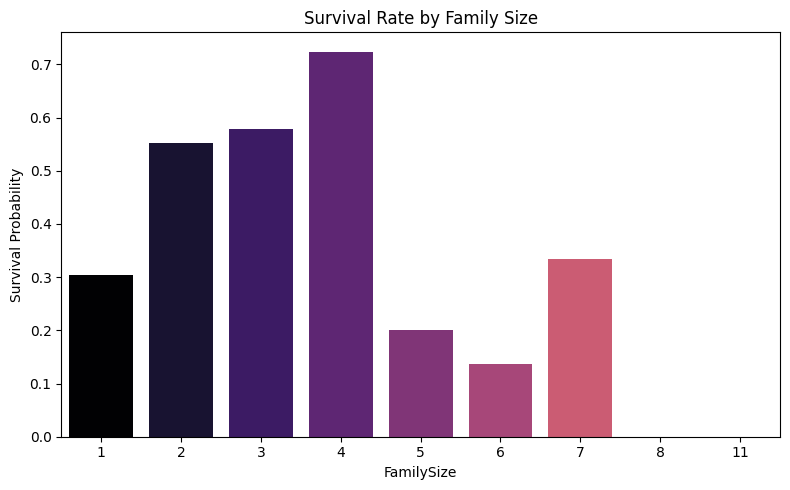

Part 5: Feature Engineering Complete & Plot Logged to MLflow!


,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,0,22.0,7.2500,S,2
1,1,1,1,38.0,71.2833,C,2
2,1,3,1,26.0,7.9250,S,1
3,1,1,1,35.0,53.1000,S,2
4,0,3,0,35.0,8.0500,S,1


🏃 View run Feature_Engineering at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0/runs/feea2c5cb8a547e58aea1ad163f005e8
🧪 View experiment at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

with mlflow.start_run(run_name="Feature_Engineering"):

    datasets = [train_data, test_data]

    for data in datasets:
        data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
        
        data['Sex'] = data['Sex'].map({'male': 0, 'female': 1}).astype(int)

    test_passenger_ids = test_data['PassengerId']

    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.barplot(
        x='FamilySize', 
        y='Survived', 
        data=train_data, 
        palette='magma', 
        ax=ax, 
        errorbar=None, 
        hue='FamilySize', 
        legend=False
    )
    
    ax.set_title('Survival Rate by Family Size')
    ax.set_ylabel('Survival Probability')
    
    plt.tight_layout()
    plt.savefig("family_size_survival.png")
    mlflow.log_artifact("family_size_survival.png")
    plt.show()

    columns_to_drop = ['Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch']
    train_data = train_data.drop(columns_to_drop, axis=1)
    test_data = test_data.drop(columns_to_drop, axis=1)

    print("Part 5: Feature Engineering Complete & Plot Logged to MLflow!")
    display(train_data.head())

## Part 6. Data Processing: One-Hot Encoding
Machine learning algorithms do math—they don't understand words! We need to convert our text-based categorical columns (`Sex` and `Embarked`) into numbers. 

* **Sex:** We will map 'male' to 0 and 'female' to 1.
* **Embarked:** We will use a technique called "One-Hot Encoding." Since there is no mathematical order to the ports (Southampton isn't "greater than" Cherbourg), we create separate binary columns for each port. 
* **Dropping Identifiers:** Columns like `Name`, `Ticket`, and `PassengerId` are unique to each person and won't help our baseline model find general survival patterns, so we will remove them from our training set.

In [10]:
with mlflow.start_run(run_name="One_Hot_Encoding"):
   
    if 'Embarked' in train_data.columns:
        train_data = pd.get_dummies(train_data, columns=['Embarked'], drop_first=True)
        test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=True)

    train_data = train_data.astype(float)
    test_data = test_data.astype(float)

    mlflow.log_param("num_features_after_encoding", len(train_data.columns) - 1)

    print("One-Hot Encoding Complete! Data is fully numeric.")
    display(train_data.head())

One-Hot Encoding Complete! Data is fully numeric.


,Survived,Pclass,Sex,Age,Fare,FamilySize,Embarked_Q,Embarked_S
0,0.0,3.0,0.0,22.0,7.2500,2.0,0.0,1.0
1,1.0,1.0,1.0,38.0,71.2833,2.0,0.0,0.0
2,1.0,3.0,1.0,26.0,7.9250,1.0,0.0,1.0
3,1.0,1.0,1.0,35.0,53.1000,2.0,0.0,1.0
4,0.0,3.0,0.0,35.0,8.0500,1.0,0.0,1.0


🏃 View run One_Hot_Encoding at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0/runs/9414cf9c58904d1e95a21d92341741de
🧪 View experiment at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0


## Part 7. Feature Selection
Feature selection is a critical step in building a robust Kaggle model. It helps reduce overfitting, improves accuracy, and makes your model more interpretable by removing noise.

We use **Information Value (IV)** to rank variables based on their predictive power, a **Correlation Matrix** to identify redundant features, and **Recursive Feature Elimination (RFE)** to let a machine learning model pick the optimal subset of columns.

Information Value (IV) Ranking:


,IV
Sex,1.304191
Fare,0.664806
Pclass,0.484692
FamilySize,0.322187
Age,0.214312
Embarked_S,0.090229
Embarked_Q,0.000051


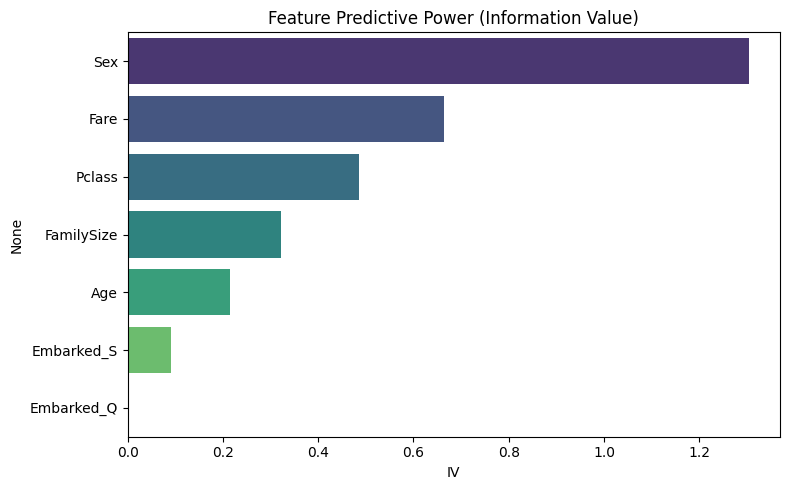

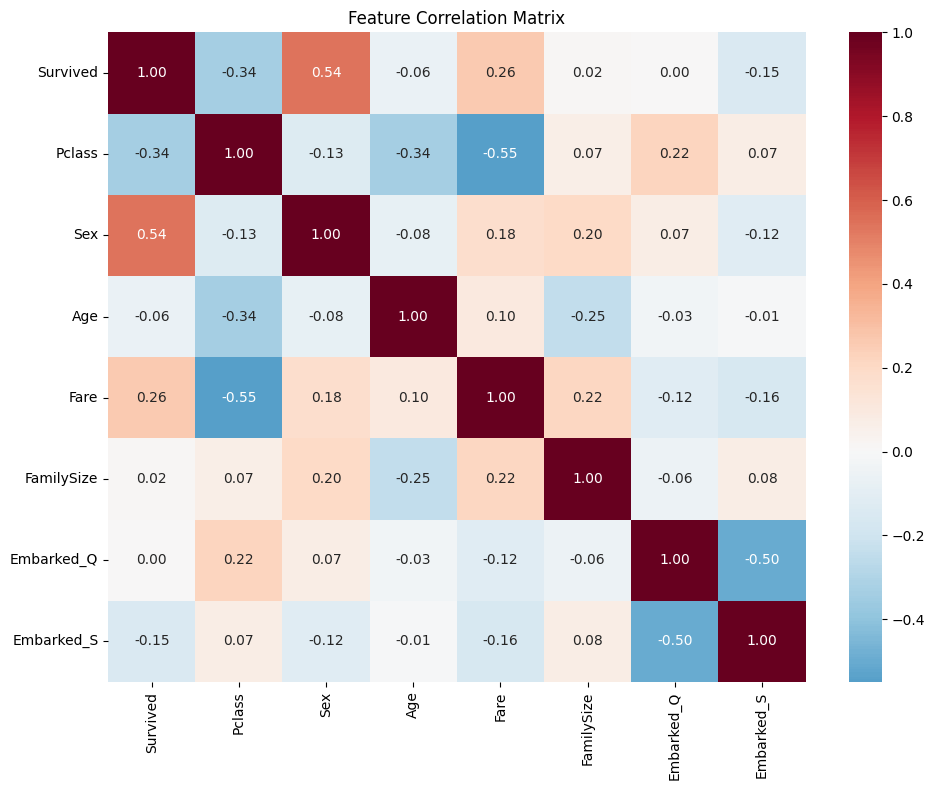


--- RFE Feature Rankings ---


,Feature,Ranking,Selected
0,Pclass,1,True
1,Sex,1,True
2,Age,1,True
3,Fare,1,True
4,FamilySize,1,True
6,Embarked_S,2,False
5,Embarked_Q,3,False


Feature Selection Complete & Artifacts logged to MLflow!
🏃 View run Feature_Selection at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0/runs/09ce4a3d29da45118aa0eca3fcf47e7e
🧪 View experiment at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE

with mlflow.start_run(run_name="Feature_Selection"):
    
    def calculate_woe_iv(dataset, feature, target):
        lst = []
        for val in dataset[feature].unique():
            all_val = dataset[dataset[feature] == val].count()[feature]
            good = dataset[(dataset[feature] == val) & (dataset[target] == 1)].count()[feature]
            bad = dataset[(dataset[feature] == val) & (dataset[target] == 0)].count()[feature]
            lst.append({'Value': val, 'All': all_val, 'Good': good, 'Bad': bad})
            
        d3 = pd.DataFrame(lst)
        d3['Distr_Good'] = d3['Good'] / (d3['Good'].sum() + 1e-6)
        d3['Distr_Bad'] = d3['Bad'] / (d3['Bad'].sum() + 1e-6)
        d3['WoE'] = np.log((d3['Distr_Good'] + 1e-2) / (d3['Distr_Bad'] + 1e-2))
        d3['IV'] = (d3['Distr_Good'] - d3['Distr_Bad']) * d3['WoE']
        return d3['IV'].sum()

    features = [col for col in train_data.columns if col != 'Survived']
    iv_values = {col: calculate_woe_iv(train_data, col, 'Survived') for col in features}
    iv_df = pd.DataFrame.from_dict(iv_values, orient='index', columns=['IV']).sort_values(by='IV', ascending=False)
    
    print("Information Value (IV) Ranking:")
    display(iv_df)
    
    fig_iv, ax_iv = plt.subplots(figsize=(8, 5))
    sns.barplot(x=iv_df['IV'], y=iv_df.index, palette='viridis', ax=ax_iv, hue=iv_df.index, legend=False)
    ax_iv.set_title('Feature Predictive Power (Information Value)')
    plt.tight_layout()
    plt.savefig("iv_ranking.png")
    mlflow.log_artifact("iv_ranking.png")
    plt.show()

    fig_corr, ax_corr = plt.subplots(figsize=(10, 8))
    sns.heatmap(train_data.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax_corr)
    ax_corr.set_title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.savefig("correlation_matrix.png")
    mlflow.log_artifact("correlation_matrix.png")
    plt.show()

    X_train = train_data.drop('Survived', axis=1)
    y_train = train_data['Survived']
    
    base_estimator = DecisionTreeClassifier(random_state=42)
    rfe = RFE(estimator=base_estimator, n_features_to_select=5, step=1)
    rfe.fit(X_train, y_train)
    
    rfe_df = pd.DataFrame({'Feature': X_train.columns, 'Ranking': rfe.ranking_, 'Selected': rfe.support_})
    rfe_df = rfe_df.sort_values(by='Ranking')
    
    print("\n--- RFE Feature Rankings ---")
    display(rfe_df)
    
    rfe_df.to_csv("rfe_rankings.csv", index=False)
    mlflow.log_artifact("rfe_rankings.csv")

    print("Feature Selection Complete & Artifacts logged to MLflow!")

## Part 8. Model Training (Decision Tree)

It is time to build our predictive model! We are going to use a **Decision Tree Classifier**. 

**Why a Decision Tree?**
* **Intuitive:** It thinks like a human playing "20 Questions" (e.g., "Is the passenger male?", "Is their Pclass 3?").
* **Robust:** Unlike many other models, Decision Trees do not require the data to be scaled or normalized.
* **Non-Linear:** It can capture complex relationships between features (like how age might matter more for certain genders).

### Model Evaluation (Cross-Validation)

If we just train our model and submit it, we are "flying blind." We need to know how accurate our model is **before** we submit it to Kaggle.

**What is K-Fold Cross-Validation?**
We split our training data into 5 parts (Folds). The computer trains on 4 parts and tests itself on the 5th part. It repeats this 5 times so every row of data gets a chance to be "the test." 

This gives us a much more honest **Accuracy Score** and tells us if our model is "Overfitting" (just memorizing the data) or actually "Learning" (finding patterns). We will use a custom `ModelTrainer` class to keep our training, MLflow logging, and submission process organized.

In [12]:
class ModelTrainer:
    def __init__(self, model, name):
        self.model = model
        self.name = name
        
    def evaluate(self, X, y):
        with mlflow.start_run(run_name=self.name):
            
            if hasattr(self.model, 'get_params'):
                mlflow.log_params(self.model.get_params())
            
            self.model.fit(X, y)
            train_accuracy = self.model.score(X, y)
            
            cv_scores = cross_val_score(self.model, X, y, cv=5)
            val_accuracy = cv_scores.mean()
            
            mlflow.log_metric("train_accuracy", train_accuracy)
            mlflow.log_metric("val_accuracy", val_accuracy)
            mlflow.log_metric("accuracy_gap", train_accuracy - val_accuracy)
            
            print(f"--- {self.name} Performance ---")
            print(f"Training Accuracy:   {train_accuracy:.2%}")
            print(f"Validation Accuracy: {val_accuracy:.2%}")
            print(f"Accuracy Gap:        {train_accuracy - val_accuracy:.2%}")
            print("-" * 35)
            
            mlflow.sklearn.log_model(
                sk_model=self.model, 
                artifact_path="model", 
                serialization_format="cloudpickle"
            )
            print(f"Model '{self.name}' saved to MLflow!")
            
            return val_accuracy

X_train_final = train_data.drop('Survived', axis=1)
y_train_final = train_data['Survived']

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
trainer = ModelTrainer(model=dt_model, name="Decision_Tree_Baseline")

tree_score = trainer.evaluate(X_train_final, y_train_final)

2026/03/31 16:04:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- Decision_Tree_Baseline Performance ---
Training Accuracy:   83.50%
Validation Accuracy: 81.04%
Accuracy Gap:        2.46%
-----------------------------------


2026/03/31 16:04:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model 'Decision_Tree_Baseline' saved to MLflow!
🏃 View run Decision_Tree_Baseline at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0/runs/0ac8b40f1d3746409dad9ffbcdbb1768
🧪 View experiment at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0


## Part 9. Model Training (Logistic Regression)

Next, we will try a **Logistic Regression**. Because Logistic Regression relies on math equations, it is highly sensitive to the scale of the data (e.g., `Fare` goes up to 500, while `FamilySize` is single digits). 

To handle this elegantly, we will build a scikit-learn **Pipeline** that mathematically scales the data (`StandardScaler`) and then trains the model. By saving the *entire pipeline* to MLflow, our inference script won't need to worry about scaling the test data manually—the pipeline will do it automatically!

In [13]:
with mlflow.start_run(run_name="Logistic_Regression_Optimized"):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=1000, solver='liblinear'))
    ])
    
    param_grid = {
        'logreg__C': [0.01, 0.1, 1, 10, 100], 
        'logreg__penalty': ['l1', 'l2']
    }
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train_final, y_train_final)
    
    best_model = grid_search.best_estimator_
    logreg_score = grid_search.best_score_
    
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("val_accuracy", logreg_score)
    
    print(f"--- BEST LOGREG MODEL ---")
    print(f"Validation Accuracy: {logreg_score:.2%}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
   
    mlflow.sklearn.log_model(
        best_model, 
        name="model", 
        serialization_format="skops",
        pip_requirements=["scikit-learn", "skops", "pandas"]
    )
    

print("\n" + "="*40)
if logreg_score > tree_score:
    print(f" Logistic Regression wins: ({logreg_score:.2%} vs {tree_score:.2%})")
else:
    print(f"Decision Tree wins: ({tree_score:.2%} vs {logreg_score:.2%})")


--- BEST LOGREG MODEL ---
Validation Accuracy: 79.24%
Best Parameters: {'logreg__C': 0.01, 'logreg__penalty': 'l2'}
🏃 View run Logistic_Regression_Optimized at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0/runs/e3c527d970d242878d9d8afd586675dd
🧪 View experiment at: https://dagshub.com/mkoko22/Titanic-Kaggle-Competition-.mlflow/#/experiments/0

Decision Tree wins: (81.04% vs 79.24%)
